### Data Cleansing and Standardization for Prophet Forecasting

**importing all dependencies**

In [2]:
import pandas as pd
from prophet import Prophet
import numpy as np
import matplotlib.pyplot as plt

Importing plotly failed. Interactive plots will not work.


**Load monthly order data for predictions**

In [4]:
df = pd.read_csv('/Users/ellasajor/__git/supply-chain-demand-forecasting/query_outputs/main_queries/q3_monthly_revenue_trends.csv')

**Rename & Sort to Prophet's Required Format**

In [5]:
#prophet's required format - ds : the date, y: value being forecasted
df = df.rename(columns={'order_month': 'ds', 'total_orders': 'y'}) 

In [6]:
#convert ds to datetime - make sure its not a string
df['ds'] = pd.to_datetime(df['ds'])

In [7]:
#sort chronologically by date
df = df.sort_values('ds').reset_index(drop=True) #reset index  drops old index labels and allows new indices to be assigned in chronilogical order
df.head() #shows first 5 rows of dataset

,ds,market,customer_segment,y,total_revenue,total_profit,avg_margin_pct,late_deliveries
0,2015-01-01,LATAM,Consumer,928,547482.50,62962.40,12.20,1545
1,2015-01-01,LATAM,Corporate,528,317973.66,28959.29,10.23,830
2,2015-01-01,LATAM,Home Office,331,186133.90,19739.05,12.12,505
3,2015-02-01,LATAM,Consumer,815,476562.84,50244.79,11.46,1341
4,2015-02-01,LATAM,Corporate,475,274771.08,32128.64,13.08,766


In [8]:
#Aggregate to one row per month - remove grouping by market and customer segment
df_monthly = df.groupby('ds', as_index=False)['y'].sum()
df_monthly = df_monthly.sort_values('ds').reset_index(drop=True)


**Limit Data to the clean window (Jan 2015 - Sept 2017)**

Data discontinuity begins Oct 2, 2017, 12:25 PM — order-logging structure changed (verified via line-items-per-order ratio: ~3.0 → 1.0). October and following months are excluded from forecast training; retained on dashboards for transparency.

In [9]:
df_monthly = df_monthly[df_monthly['ds'] < '2017-10-01'] #exclude October altogether - incomplete month with mid way change in order logging
df_monthly = df_monthly.reset_index(drop=True)

print(df_monthly.head()) #check first 5 rows of dataset
print(df_monthly.tail()) #check last 5 rows of dataset 
print(df_monthly.shape) 

          ds     y
0 2015-01-01  1787
1 2015-02-01  1585
2 2015-03-01  1781
3 2015-04-01  1710
4 2015-05-01  1776
           ds     y
28 2017-05-01  1763
29 2017-06-01  1676
30 2017-07-01  1776
31 2017-08-01  1768
32 2017-09-01  1723
(33, 2)


**Training the model**

In [10]:
#.iloc is positional slicing (index - locate)
#.copy creates an independent dataframe in memory so the original is not affected
#Train on everything except the last 6 months
train = df_monthly.iloc[:-6].copy() 

#Hold last 6 months for evaluation of model 
test = df_monthly.iloc[-6:].copy()

#confirm split is accurate
print(train.shape)
print(test.shape)
print(train.tail())
print(test)

(27, 2)
(6, 2)
           ds     y
22 2016-11-01  1721
23 2016-12-01  1763
24 2017-01-01  1745
25 2017-02-01  1614
26 2017-03-01  1782
           ds     y
27 2017-04-01  1739
28 2017-05-01  1763
29 2017-06-01  1676
30 2017-07-01  1776
31 2017-08-01  1768
32 2017-09-01  1723


In [11]:
#fit prohphet on the training data only
model = Prophet()
model.fit(train)

13:08:40 - cmdstanpy - INFO - Chain [1] start processing
13:08:40 - cmdstanpy - INFO - Chain [1] done processing


Ask the model to predict the test period 
- for comparison between predicted and real data

In [12]:
#1. set up data frame of future dates

#periods - additional rows beyond training data
#MS - "Month Start" - space out new rows by month
future = model.make_future_dataframe(periods=6, freq='MS')
future.tail(8) #shows 2 months of training data into 6 months of predicted data (see continuity between real vs predicted)

,ds
25,2017-02-01
26,2017-03-01
27,2017-04-01
28,2017-05-01
29,2017-06-01
30,2017-07-01
31,2017-08-01
32,2017-09-01


In [13]:
#2. generate actual predictions

#yhat - model's point prediction (best-fit guess)
#yhat_lower & yhat_upper - uncertaintly interval (margin of error - answer could lie anywhere within this interval)

forecast = model.predict(future)
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(6))
print(test.tail(6)) #visually compare to test real data


           ds         yhat   yhat_lower   yhat_upper
27 2017-04-01  1700.094203  1683.753625  1713.977337
28 2017-05-01  1758.636741  1743.923389  1773.262543
29 2017-06-01  1691.707152  1676.705717  1706.731410
30 2017-07-01  1748.827072  1734.362342  1763.416484
31 2017-08-01  1753.106364  1738.971732  1767.984765
32 2017-09-01  1709.980757  1695.275068  1723.840904
           ds     y
27 2017-04-01  1739
28 2017-05-01  1763
29 2017-06-01  1676
30 2017-07-01  1776
31 2017-08-01  1768
32 2017-09-01  1723


**Calculate MAPE**
- MAPE = Mean Absoulte Percentage Error
- on average how far off was the prediction
- purpose: determine the accuracy of the model

In [14]:
# Merge predictions with actuals on date, so each row lines up correctly
comparison = forecast[['ds', 'yhat']].merge(test[['ds', 'y']], on='ds')

#MAPE formula (%): AVG(|actual - predicted| / actual) * 100 
comparison['abs_pct_error'] = np.abs(comparison['y'] - comparison['yhat']) / comparison['y'] * 100
  #calculates abs_pct_error for each row - shown as a new column

mape = comparison['abs_pct_error'].mean()
  #mean of % error for each row

print(comparison)
print(f"\nMAPE: {mape:.2f}%")

          ds         yhat     y  abs_pct_error
0 2017-04-01  1700.094203  1739       2.237251
1 2017-05-01  1758.636741  1763       0.247491
2 2017-06-01  1691.707152  1676       0.937181
3 2017-07-01  1748.827072  1776       1.530007
4 2017-08-01  1753.106364  1768       0.842400
5 2017-09-01  1709.980757  1723       0.755615

MAPE: 1.09%


**Visualize the forecast**

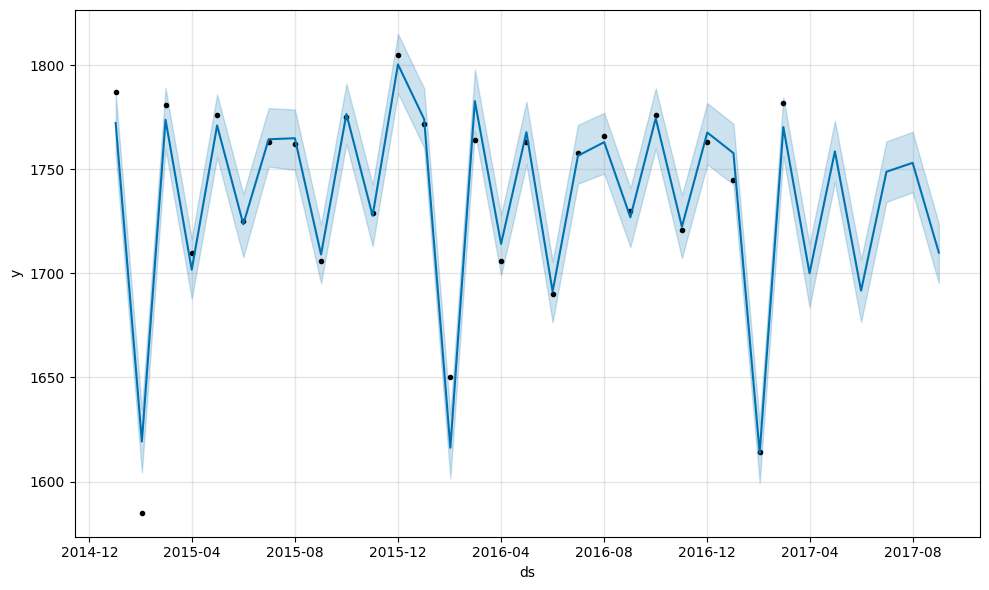

In [15]:
fig = model.plot(forecast)
#black dots - actual order counts each month
#solid blue line - predicted yhat line
#light blue band - uncertaintlu interval (yhat lower - yhat upper)

#pattern shown with a significant drop at the start of each year 
#Feb 2015, Feb 2016, Feb 2017 


**Analyzing a Recurring Pattern**

A recurring February dip appears in all three years of available data, suggesting possible seasonality. However, with only three yearly cycles of data, it is hard to fully confirm this pattern as seasonality rather than a 3 year coincidence.


In [16]:
# Add a month & year column 
df_monthly['month'] = pd.to_datetime(df_monthly['ds']).dt.month
df_monthly['year'] = pd.to_datetime(df_monthly['ds']).dt.year


In [17]:
#1. Analyze Februay's order volume individually, across all three years
february_data = df_monthly[df_monthly['month'] == 2][['ds', 'y']]
print("February each year:")
print(february_data)


February each year:
           ds     y
1  2015-02-01  1585
13 2016-02-01  1650
25 2017-02-01  1614


In [18]:
#2. Compare against the overall average (excluding Feb, so it's a fair comparison)
overall_avg = df_monthly[df_monthly['month'] != 2]['y'].mean()
feb_avg = df_monthly[df_monthly['month'] == 2]['y'].mean()

print(f"\nAverage order volume, all months except Feb: {overall_avg:.0f}")
print(f"Average order volume, February only: {feb_avg:.0f}")
print(f"Feb is {(overall_avg - feb_avg) / overall_avg * 100:.1f}% lower than the non-Feb average")


Average order volume, all months except Feb: 1750
Average order volume, February only: 1616
Feb is 7.6% lower than the non-Feb average


In [19]:
#3. See the full month-by-month average ranking, for context
monthly_avg = df_monthly.groupby('month')['y'].mean().sort_values()
print("\nAverage order volume by calendar month (lowest to highest):")
print(monthly_avg)
print("February is shown to have the lowest average order volume by 81 orders")


Average order volume by calendar month (lowest to highest):
month
2     1616.333333
6     1697.000000
4     1718.333333
9     1719.666667
11    1725.000000
8     1765.333333
7     1765.666667
5     1767.333333
1     1768.000000
10    1775.500000
3     1775.666667
12    1784.000000
Name: y, dtype: float64
February is shown to have the lowest average order volume by 81 orders


Conclusion

February consistently shows the lowest order volume across all three years in the dataset (1,585 in 2015, 1,650 in 2016, 1,614 in 2017), averaging 7.6% below the rest of the year and 81 orders below the next-lowest month. This pattern recurs independently in each year rather than being driven by a single outlier, which is suggestive of real seasonality — but with only three yearly cycles available, this should be treated as a hypothesis rather than statistically confirmed seasonality. More historical data would be needed to validate it with confidence.



**Final Forecasting Visual for Tableau Dashboard**

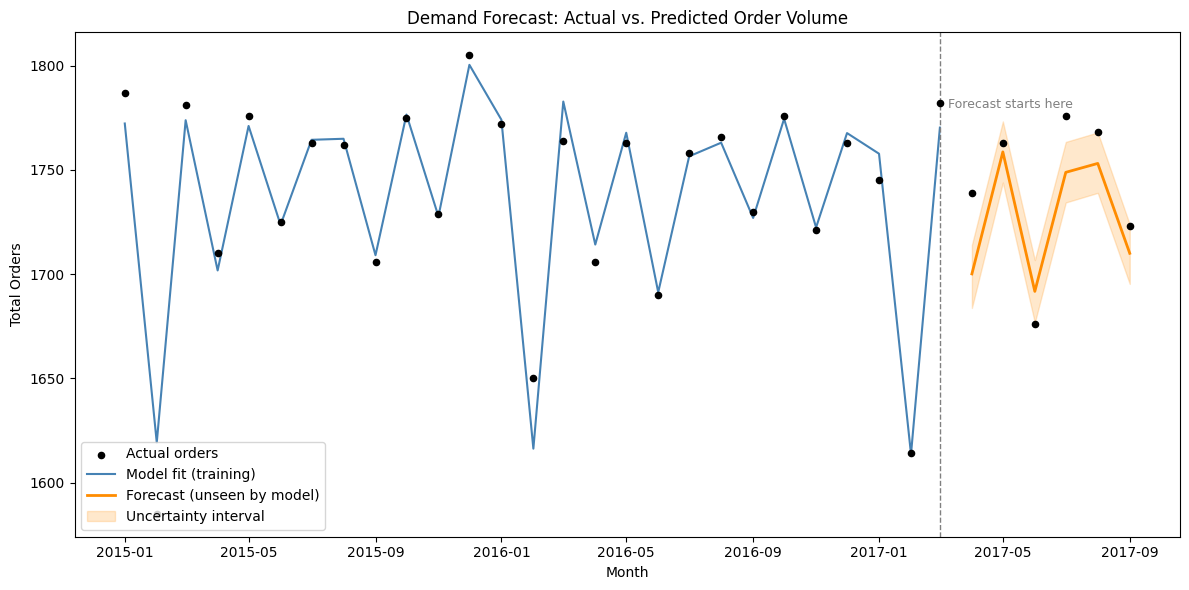

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))

# Full historical actuals (black dots) - both train and test periods
ax.scatter(df_monthly['ds'], df_monthly['y'], color='black', s=20, label='Actual orders', zorder=5)

# Model's fitted line over the TRAINING period only
train_forecast = forecast[forecast['ds'] <= train['ds'].max()]
ax.plot(train_forecast['ds'], train_forecast['yhat'], color='steelblue', linewidth=1.5, label='Model fit (training)')

# Model's TRUE forecast over the holdout period
test_forecast = forecast[forecast['ds'] > train['ds'].max()]
ax.plot(test_forecast['ds'], test_forecast['yhat'], color='darkorange', linewidth=2, label='Forecast (unseen by model)')
ax.fill_between(test_forecast['ds'], test_forecast['yhat_lower'], test_forecast['yhat_upper'],
                color='darkorange', alpha=0.2, label='Uncertainty interval')

# Vertical line marking the train/test split
split_date = train['ds'].max()
ax.axvline(split_date, color='gray', linestyle='--', linewidth=1)
ax.text(split_date, ax.get_ylim()[1]*0.98, '  Forecast starts here', fontsize=9, color='gray')

ax.set_title('Demand Forecast: Actual vs. Predicted Order Volume')
ax.set_xlabel('Month')
ax.set_ylabel('Total Orders')
ax.legend(loc='lower left')
plt.tight_layout()
plt.savefig('forecast_chart.png', dpi=300, bbox_inches='tight')
plt.show()

**Exporting Forecast Data for Tableau**

In [ ]:
# Combine everything Tableau will need into one clean export
export_df = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].merge(
    df_monthly[['ds', 'y']], on='ds', how='left'
)

# Add a column period_type so Tableau can distinguish fitted/trained on vs. true forecast
export_df['period_type'] = export_df['ds'].apply(
    lambda d: 'Forecast' if d > split_date else 'Historical'
)

export_df.to_csv('../query_outputs/main_queries/model_forecast_output.csv', index=False)
export_df.tail(10)

,ds,yhat,yhat_lower,yhat_upper,y,period_type
23,2016-12-01,1767.666572,1753.618098,1781.858224,1763,Historical
24,2017-01-01,1757.756325,1743.682350,1772.280628,1745,Historical
25,2017-02-01,1613.630606,1598.651137,1628.484359,1614,Historical
26,2017-03-01,1770.291964,1756.278966,1785.076499,1782,Historical
27,2017-04-01,1700.094203,1686.671323,1714.872660,1739,Forecast
28,2017-05-01,1758.636741,1744.425815,1772.973893,1763,Forecast
29,2017-06-01,1691.707152,1676.224681,1706.353357,1676,Forecast
30,2017-07-01,1748.827072,1734.257204,1762.626739,1776,Forecast
31,2017-08-01,1753.106364,1737.953788,1767.409139,1768,Forecast
32,2017-09-01,1709.980757,1695.791515,1724.596398,1723,Forecast


**Forecasting model II: Forward-looking Forecast (using full validated history)**